In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

In [ ]:
np.random.seed(42)
n_samples=400
X1=np.random.uniform(-3,3,size=n_samples)
X2=np.random.uniform(-3,3,size=n_samples)
X=np.column_stack((X1,X2))

In [ ]:
from sklearn import linear_model
y=X1**2-X2**2 + X1*X2 +np.random.normal(0,3,n_samples)
X_train,X_test,y_train,y_test=train_test_split(X ,y ,test_size=0.3 ,random_state=42)
linear_model=LinearRegression()
degree=6
poly_model=make_pipeline(PolynomialFeatures(degree),StandardScaler(),linear_model)
ridge_model=make_pipeline(PolynomialFeatures(degree),StandardScaler(),Ridge(alpha=0.1))
lasso_model=make_pipeline(PolynomialFeatures(degree),StandardScaler(),Lasso(alpha=0.1))
models={
    "linear":LinearRegression(),
    "poly":poly_model,
    "ridge":ridge_model,
    "lasso":lasso_model
}
predictions={}
metrics={}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    predictions[name]=y_pred
    mse=mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    metrics[name]={'MSE':mse,'R2':r2}

In [ ]:
print("-" * 50)
print(f"{'Model':<20} | {'Test MSE':<10} | {'R2 Score':<8}")
print("-" * 50)
for name, m in metrics.items():
    print(f"{name:<20} | {m['MSE']:<10.2f} | {m['R2']:<8.4f}")
print("-" * 50)

# Extract and compare coefficients (Variance demonstration)
poly_coefs = poly_model.named_steps['linearregression'].coef_
ridge_coefs = ridge_model.named_steps['ridge'].coef_
lasso_coefs = lasso_model.named_steps['lasso'].coef_

print("\nVariance / Complexity Reduction:")
print(f"Standard Poly Sum of Squared Coefs: {np.sum(poly_coefs**2):.2f} (High Variance)")
print(f"Ridge Poly Sum of Squared Coefs:    {np.sum(ridge_coefs**2):.2f} (Constrained)")
print(f"LASSO Non-Zero Coefficients:        {np.sum(lasso_coefs != 0)} out of {len(lasso_coefs)} (Sparse)\n")

--------------------------------------------------
Model                | Test MSE   | R2 Score
--------------------------------------------------
linear               | 35.82      | -0.0165 
poly                 | 9.53       | 0.7297  
ridge                | 9.55       | 0.7291  
lasso                | 9.16       | 0.7401  
--------------------------------------------------

Variance / Complexity Reduction:
Standard Poly Sum of Squared Coefs: 75.78 (High Variance)
Ridge Poly Sum of Squared Coefs:    68.31 (Constrained)
LASSO Non-Zero Coefficients:        6 out of 28 (Sparse)



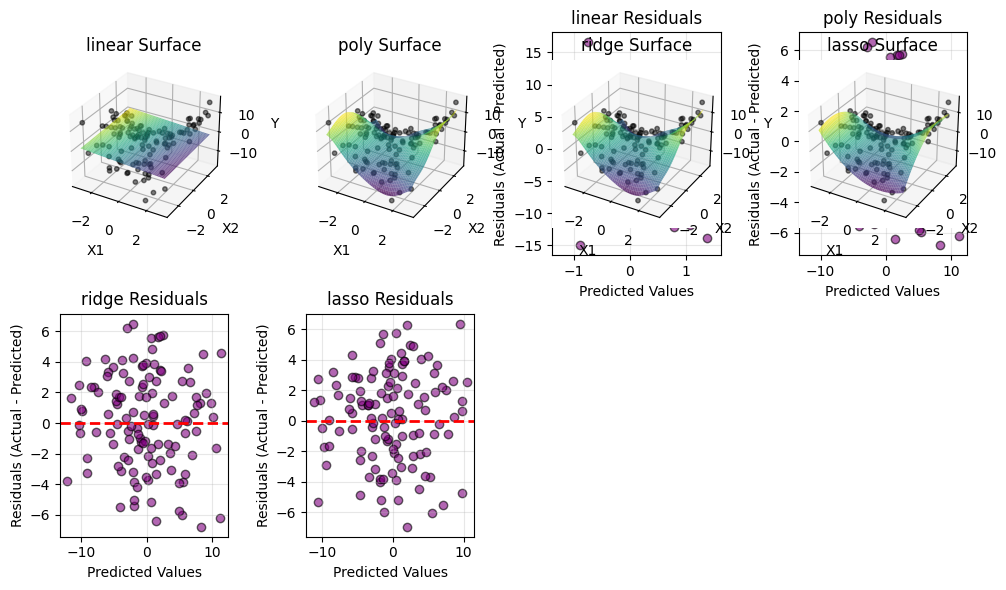

In [ ]:

fig=plt.figure(figsize=(10,6))
x1_range=np.linspace(-3,3,50)
x2_range=np.linspace(-3,3,50)
X1_mesh,X2_mesh=np.meshgrid(x1_range,x2_range)
X_mesh = np.column_stack((X1_mesh.ravel(), X2_mesh.ravel()))
plot_positions=[1,2,3,4,5]
for i,(name,model) in enumerate(models.items()):
  # 3D Surface Plot
    ax = fig.add_subplot(2, 4, plot_positions[i], projection='3d')
    Y_mesh_pred = model.predict(X_mesh).reshape(X1_mesh.shape)
    # Plot true data points (test set)
    ax.scatter(X_test[:, 0], X_test[:, 1], y_test, color='black', alpha=0.5, label='Test Data', s=10)
    # Plot predicted surface
    ax.plot_surface(X1_mesh, X2_mesh, Y_mesh_pred, cmap='viridis', alpha=0.7)
    ax.set_title(f'{name} Surface')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Y')
    # 2D Residual Plot
    ax_res = fig.add_subplot(2, 4, plot_positions[i] + 2)
    residuals = y_test - predictions[name]
    ax_res.scatter(predictions[name], residuals, color='purple', alpha=0.6, edgecolors='k')
    ax_res.axhline(0, color='red', linestyle='--', linewidth=2)
    ax_res.set_title(f'{name} Residuals')
    ax_res.set_xlabel('Predicted Values')
    ax_res.set_ylabel('Residuals (Actual - Predicted)')
    ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()